# Applications of linear algebra

In this section of the lecture, we will recall some tools from linear algebra. Many of these tools are implemented in NumPy for us. We will look at the following linear algebraic objects:
- Eigenvalues and eigenvectors
- Singular values
- Singular value decomposition (SVD)
- SVD applied to image compression

In [1]:
import numpy as np
import numpy.linalg as nl
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

A = np.array([[1,2,3],[4,5,6],[7,8,9]])
print(A)

[[1 2 3]
 [4 5 6]
 [7 8 9]]


# Recall eigenvalues and eigenvectors

Let $A$ be an $n\times n$ (square) matrix. We can view the action of multiplying a vector by $A$ as a linear map, where $x\mapsto Ax$. Every linear map acts by some combination of rotation and rescaling. We are interested in decomposing linear maps into these two component actions (rotation and scaling). In the case that $A$ is square, we can sometimes accomplish this by **diagonalizing** $A$. In order to diagonalize $A$, we must know information about its **eigvenvalues** and **eigenvectors**. 

## Definitions

If there exists a vector $x$ and a number $\lambda$, which makes the following equation true,
$$ Ax=\lambda x,$$
then we say that $\lambda$ is an **eigenvalue** of $A$ with corresponding **eigenvector** $x$. Let $P$ denote the matrix whose columns are the eigenvectors of $A$ and let $D$ denote the matrix whose diagonal entries are the eigenvalues of $A$ and all other entries are zero. If $P$ has an inverse (a matrix $P^{-1}$, such that $PP^{-1}=I$), then $A=PDP^{-1}$. We call this factorization a **diagonalization** of $A$.

In [2]:
# Eigenvalues and eigenvectors in NumPy

eigenvalues, eigenvectors = nl.eig(A)
# eigenvalues as a vector and 
# eigenvectors as the matrix P

P = eigenvectors
D = np.diag(eigenvalues)
inv_P = nl.inv(P)

# Check diagonalization
#print(np.matmul(P,np.matmul(D,inv_P)))
# Can also use "@"
#print(P@D@inv_P)
print(nl.eig(A))

EigResult(eigenvalues=array([ 1.61168440e+01+0.j, -1.11684397e+00+0.j, -4.29954797e-16+0.j]), eigenvectors=array([[-0.23197069+0.j, -0.78583024+0.j,  0.40824829+0.j],
       [-0.52532209+0.j, -0.08675134+0.j, -0.81649658+0.j],
       [-0.8186735 +0.j,  0.61232756+0.j,  0.40824829+0.j]]))


## Downsides of diagonalization

We cannot always diagonalize every matrix. Namely, diagonalization is only defined for square matrices (and even every square matrix is not diagonalizable). However, as diagonalization is such a useful tool, we would like a way to generalize it to other matrices. This is the idea behind **singular value decomposition**. 

## Singular value decomposition

Our matrix $A$ may not be square, but $AA^T$ ($A$ multiplied by its own transpose) always will be! We call the eigenvalues of $AA^T$ the **singular values** of $A$. Let $\Sigma$ denote the diagonal matrix whose diagonal entries are the singular values of $A$. Let $U$ denote the matrix whose columns are the eigenvectors of $AA^T$ and let $V$ denote the matrix whose columns are the eigenvectors of $A^TA$. Then, 
$$A=U\Sigma V^T,$$
is said to be a **singular value decomposition** (SVD) of $A$.

In [3]:
# SVD in Numpy linalg
print(nl.svd(A))

SVDResult(U=array([[-0.21483724,  0.88723069,  0.40824829],
       [-0.52058739,  0.24964395, -0.81649658],
       [-0.82633754, -0.38794278,  0.40824829]]), S=array([1.68481034e+01, 1.06836951e+00, 3.35890790e-16]), Vh=array([[-0.47967118, -0.57236779, -0.66506441],
       [-0.77669099, -0.07568647,  0.62531805],
       [-0.40824829,  0.81649658, -0.40824829]]))


# Application to image compression

Every digital image (we will describe grayscale images for brevity, colour is the same but with three different arrays one for red, one for green, one for blue) is an array of pixels whose values describe the intensity of the colour in each pixel. We can thus naturally interpret a digital image as a (large) matrix. We may **compress** an image using SVD in the following way:
- Let $A$ denote the array representing the image
- Compute the SVD of $A$ i.e. $A=U\Sigma V^T$
- Set as many *small* singular values as needed to zero for the desired compression.

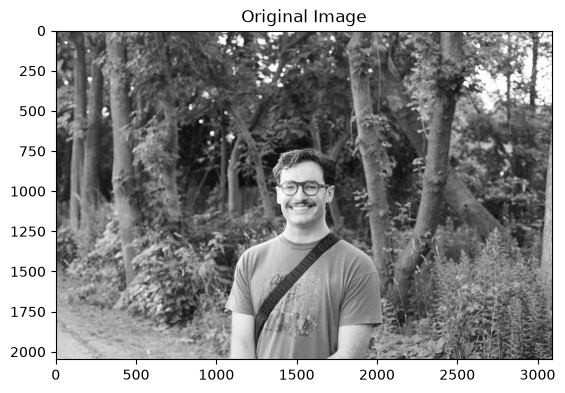

In [5]:
# read in image using matplotlib.image
raw_img=mpimg.imread('../Files/john.jpg')
# the image I imported is in colour, we want greyscale
def rgb2gray(rgb):
    return np.dot(rgb[...,:3], [0.299, 0.587, 0.114])
# map the colour values into greyscale
img = rgb2gray(raw_img)

# Show the image
plt.title("Original Image")
imgplot=plt.imshow(img, cmap='grey')

In [8]:
img = "../Files/john.jpg"
def compress(file, tol):
    # file we want to read in
    # tol - how small the singular values can be
    #read in the image
    raw_img = mpimg.imread(file ,True) 
    # make greyscale
    img = rgb2gray(raw_img)
    #Perform SVD
    U,S,V = nl.svd(img) 
    counter = 0
     
    #Remove all singular values below tol
    for i in range(S.shape[0]): 
        if S[i] < tol:
            S[i] = 0
            counter += 1 #Count the removed singular values

    S = np.diag(S) #Create the diagonal matrix of S
 
    #Add zeros to S to fix the dimension
    zero_v = np.zeros((U.shape[1] - S.shape[0], S.shape[1])) 
    S = np.vstack((S, zero_v))
    zero_h = np.zeros((S.shape[0], V.shape[0] - S.shape[1]))
    S = np.hstack((S, zero_h))
 
    #Construct the new image
    newimg = U@S@V
    #Save the compressed image
    plt.imsave(f"svd{tol}.jpg",newimg,cmap='gray')
compress(img,100)
compress(img,1000)
compress(img,5000)
compress(img,10000)
compress(img,100000)